In [1]:
!pip install torch


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
PATH = "../Datasets/UCI Dynamic Gas Mixtures"

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import copy
import seaborn as sns

In [5]:
class BaselineLSTM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channels = channels

        self.pooling = nn.AvgPool1d(kernel_size=5, stride=5)

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=self.channels, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=False)

        self.lin_head = nn.Linear(in_features=64, out_features=2)

    def forward(self, x):
        x = self.pooling(x)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        x = h[-1]
        pred = self.lin_head(x)
        return pred

In [6]:
model = BaselineLSTM(channels=16)

In [7]:
x = torch.randn(4, 16, 5000)
y = model(x)

print(y.shape)
assert y.shape == torch.Size([4, 2])
print("се ок")

torch.Size([4, 2])
се ок


In [8]:
X = pd.read_csv(PATH + "/ethylene_methane.txt", sep=r'\s+', skiprows=1, names=['Time', 'Co', 'Ethylene'] + [f's{i}' for i in range(1, 17)])

In [9]:
X

,Time,Co,Ethylene,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16
0,0.00,0.0,0.0,-41.98,2067.64,-37.13,2.28,8.63,-26.62,-8.46,-0.33,3437.73,2728.14,4054.03,4007.89,4478.27,5056.98,3639.09,3128.49
1,0.01,0.0,0.0,-46.50,2067.88,-28.56,13.69,-12.35,-25.81,-5.04,-5.04,3432.44,2734.47,4038.62,4019.40,4496.72,5051.81,3636.97,3115.03
2,0.02,0.0,0.0,-36.16,2055.81,-10.89,8.63,-2.93,-30.34,-9.27,-2.12,3438.61,2719.97,4030.92,4025.48,4489.54,5057.35,3641.81,3105.24
3,0.03,0.0,0.0,-50.36,2053.68,-31.96,-0.65,-8.29,-21.60,7.98,2.28,3429.51,2720.50,4040.22,4000.87,4485.44,5049.60,3642.72,3124.84
4,0.04,0.0,0.0,-37.30,2081.17,-36.16,3.26,5.05,-26.14,-7.48,-0.65,3436.85,2719.71,4029.64,4007.25,4499.12,5057.35,3674.30,3147.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4178499,41790.15,0.0,0.0,2348.01,1599.24,1329.94,1488.62,1031.11,1431.76,1335.58,1506.05,3300.43,2634.70,1156.91,975.15,972.41,929.27,1211.47,948.94
4178500,41790.16,0.0,0.0,2341.81,1605.37,1333.28,1479.61,1022.80,1421.56,1336.00,1500.45,3277.72,2640.67,1155.49,975.15,963.60,938.42,1222.74,937.25
4178501,41790.17,0.0,0.0,2345.78,1604.06,1337.47,1475.10,1022.61,1423.68,1345.63,1504.76,3299.56,2622.24,1153.47,964.18,978.68,949.92,1204.32,921.50
4178502,41790.18,0.0,0.0,2350.25,1594.86,1323.68,1492.49,1041.03,1434.53,1338.72,1508.85,3296.69,2640.15,1150.03,971.04,976.92,940.76,1212.09,946.99


In [10]:
time = X["Time"].to_numpy()
y = X[["Co", "Ethylene"]].to_numpy(dtype=np.float32)
X = X[[f"s{i}" for i in range(1, 17)]].to_numpy(dtype=np.float32)

In [11]:
X

array([[ -41.98, 2067.64,  -37.13, ..., 5056.98, 3639.09, 3128.49],
       [ -46.5 , 2067.88,  -28.56, ..., 5051.81, 3636.97, 3115.03],
       [ -36.16, 2055.81,  -10.89, ..., 5057.35, 3641.81, 3105.24],
       ...,
       [2345.78, 1604.06, 1337.47, ...,  949.92, 1204.32,  921.5 ],
       [2350.25, 1594.86, 1323.68, ...,  940.76, 1212.09,  946.99],
       [2348.01, 1598.8 , 1338.93, ...,  934.14, 1201.46,  932.38]],
      shape=(4178504, 16), dtype=float32)

In [12]:
y

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(4178504, 2), dtype=float32)

In [13]:
def find_segments(target):
    changed = np.any(target[1:] != target[:-1], axis=1)

    boundaries = np.concatenate([
        [0],
        np.flatnonzero(changed) + 1,
        [len(target)],
    ])

    return [
        {
            "start": int(start),
            "end": int(end),
            "target": np.median(target[start:end], axis=0),
        }
        for start, end in zip(boundaries[:-1], boundaries[1:])
    ]

In [14]:
window_size = 50 * 100

In [15]:
target_step = 0.5

In [16]:
target_step = np.array([0.5, 0.5], dtype=np.float32)
y_clean = np.round(y / target_step) * target_step

In [17]:
segments = find_segments(y_clean)

In [18]:
len(segments)

352

In [19]:
segments

[{'start': 0, 'end': 10000, 'target': array([0., 0.], dtype=float32)},
 {'start': 10000,
  'end': 19974,
  'target': array([133.5,   0. ], dtype=float32)},
 {'start': 19974, 'end': 29974, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 29974, 'end': 49975, 'target': array([0., 0.], dtype=float32)},
 {'start': 49975, 'end': 59975, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 59975, 'end': 69975, 'target': array([0., 0.], dtype=float32)},
 {'start': 69975, 'end': 79975, 'target': array([ 0., 10.], dtype=float32)},
 {'start': 79975, 'end': 89975, 'target': array([0., 0.], dtype=float32)},
 {'start': 89975, 'end': 99975, 'target': array([0. , 6.5], dtype=float32)},
 {'start': 99975, 'end': 109975, 'target': array([0., 0.], dtype=float32)},
 {'start': 109975,
  'end': 119975,
  'target': array([133.5,   0. ], dtype=float32)},
 {'start': 119975, 'end': 129975, 'target': array([0., 0.], dtype=float32)},
 {'start': 129975,
  'end': 139975,
  'target': array([233.5,   0. 

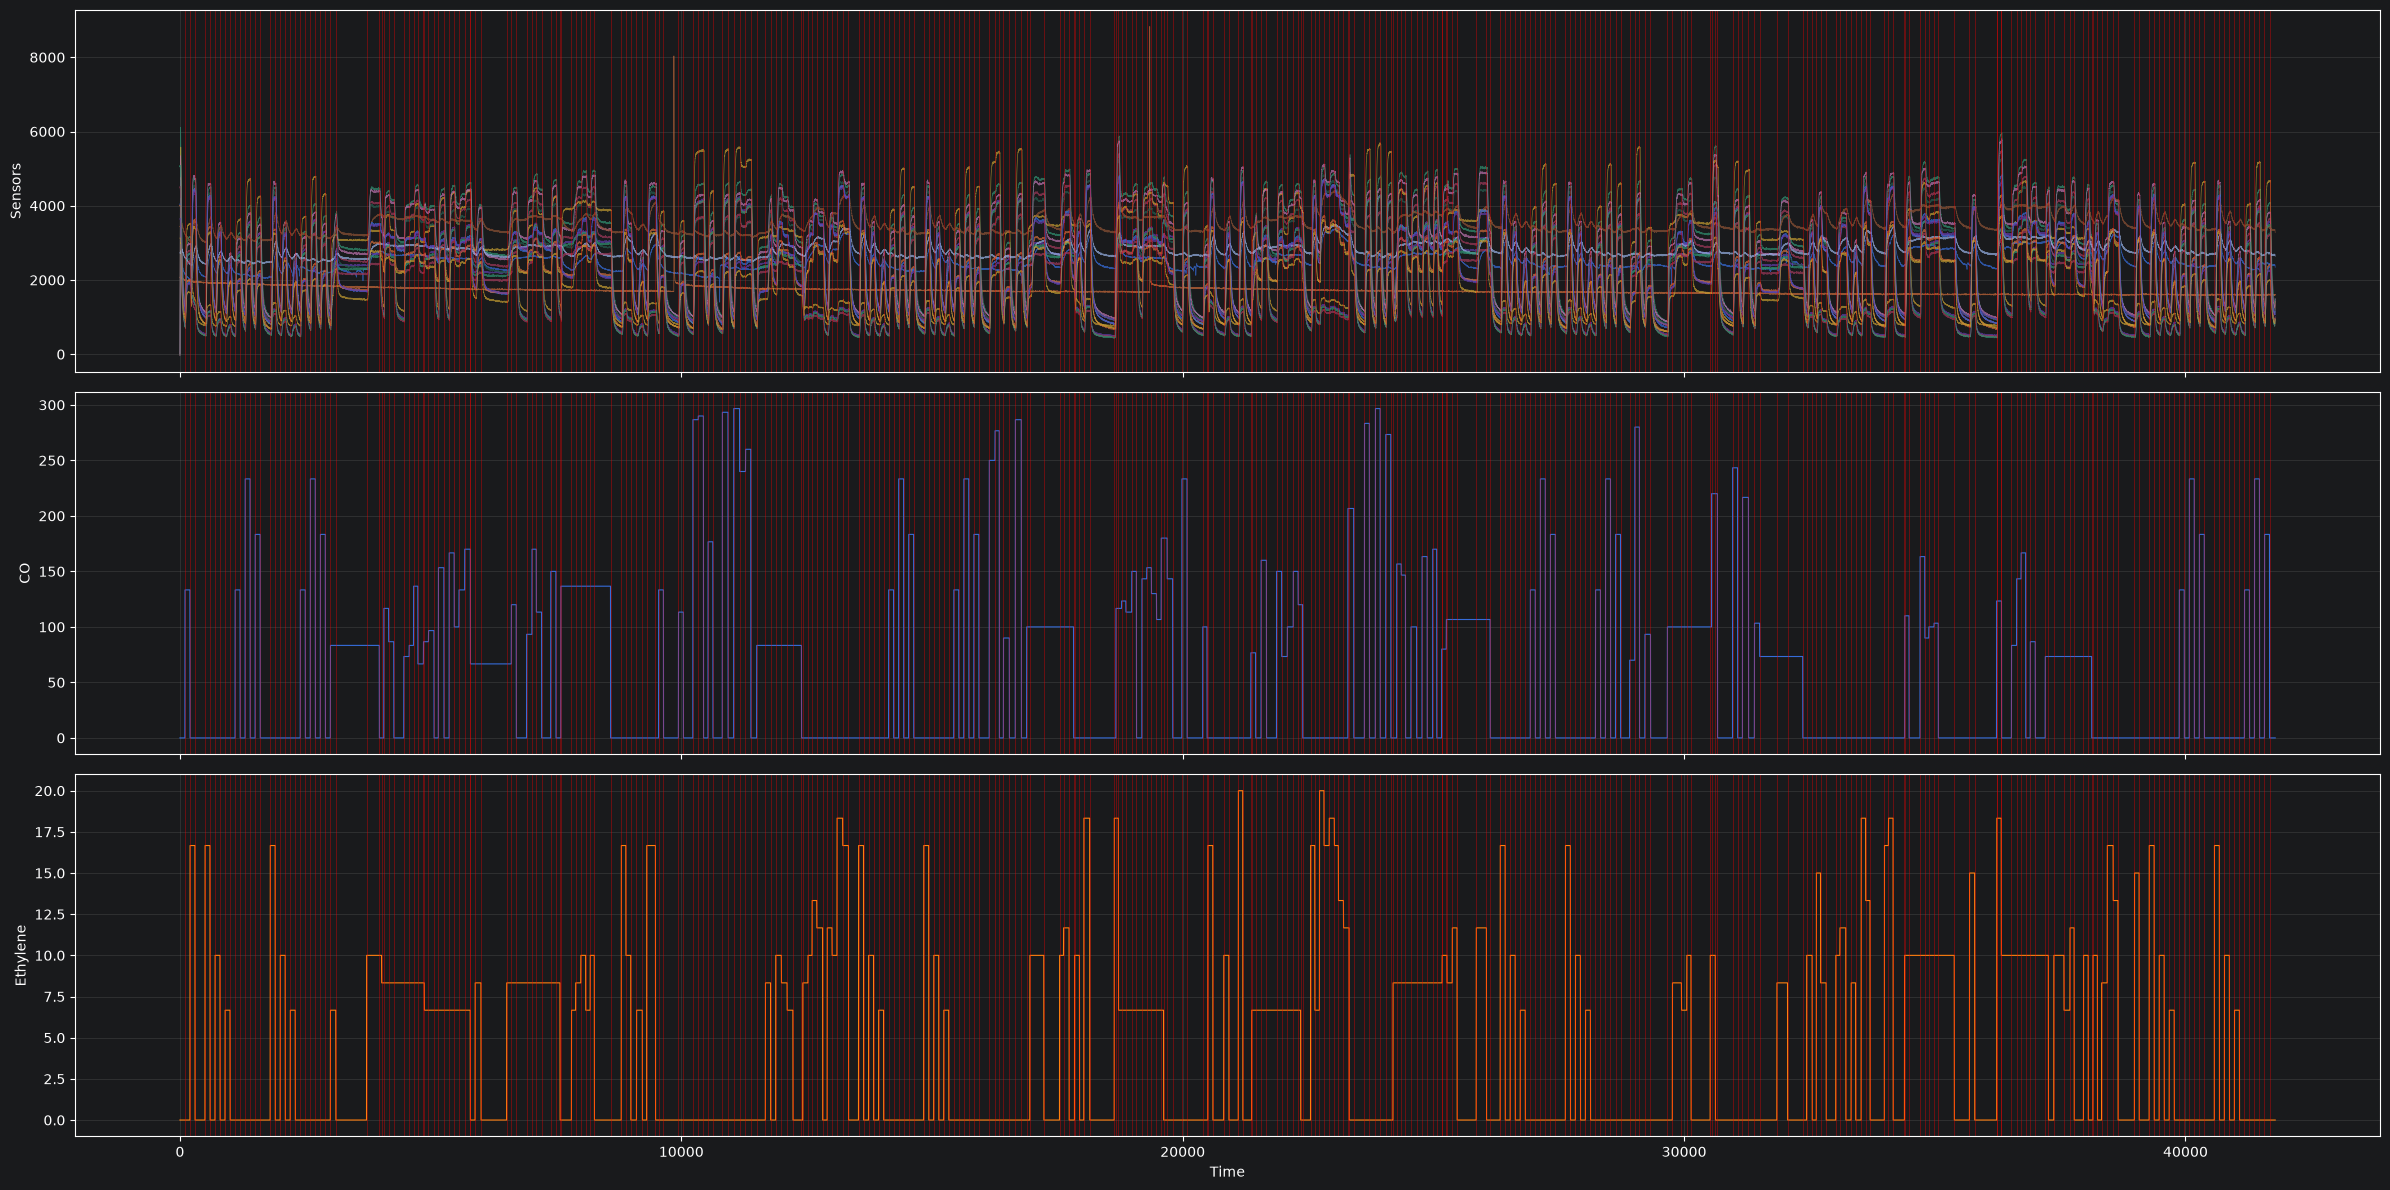

In [20]:
plot_step = 100

fig, axes = plt.subplots(3, 1, figsize=(24, 12), sharex=True)

axes[0].plot(
    time[::plot_step],
        X[::plot_step],
    linewidth=0.5,
    alpha=0.7,
)
axes[0].set_ylabel("Sensors")

axes[1].plot(
    time[::plot_step],
    y[::plot_step, 0],
    linewidth=0.8,
)
axes[1].set_ylabel("CO")

axes[2].plot(
    time[::plot_step],
    y[::plot_step, 1],
    color="tab:orange",
    linewidth=0.8,
)
axes[2].set_ylabel("Ethylene")
axes[2].set_xlabel("Time")

for segment in segments[1:]:
    boundary_time = time[segment["start"]]
    for ax in axes:
        ax.axvline(boundary_time, color="red", linewidth=0.5, alpha=0.5)
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [21]:
def make_window_indices(segments, window_size=5000, stride=100):
    samples = []

    for segment in segments:
        segment_start = segment["start"]
        segment_end = segment["end"]

        for end in range(
            segment_start + window_size,
            segment_end + 1,
            stride,
        ):
            start = end - window_size
            samples.append((start, end))

    return samples

In [22]:
generator = np.random.default_rng(42)
indices = generator.permutation(len(segments))

n_train = int(0.70 * len(indices))
n_val = int(0.15 * len(indices))

train_segments = [segments[i] for i in indices[:n_train]]
val_segments = [segments[i] for i in indices[n_train:n_train + n_val]]
test_segments = [segments[i] for i in indices[n_train + n_val:]]

train_samples = make_window_indices(train_segments, window_size=5000, stride=100)
val_samples = make_window_indices(val_segments, window_size=5000, stride=500)
test_samples = make_window_indices(test_segments, window_size=5000, stride=500)

print(
    len(train_samples),
    len(val_samples),
    len(test_samples),
)

17478 736 829


In [23]:
class SensorDataset(Dataset):
    def __init__(self, signals, target, samples, signal_mean, signal_std, target_mean, target_std):
        self.signals = np.asarray(signals, dtype=np.float32)
        self.target = np.asarray(target, dtype=np.float32)
        self.samples = samples

        self.signal_mean = np.asarray(signal_mean, dtype=np.float32)
        self.signal_std = np.asarray(signal_std, dtype=np.float32)

        self.target_mean = np.asarray(target_mean, dtype=np.float32)
        self.target_std = np.asarray(target_std, dtype=np.float32)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        start, end = self.samples[index]

        # Сначала [time, channels], чтобы broadcasting работал по каналам
        x = self.signals[start:end]
        x = (x - self.signal_mean) / self.signal_std
        x = x.T  # [channels, time]

        y = self.target[end - 1]
        y = (y - self.target_mean) / self.target_std

        return torch.from_numpy(x), torch.from_numpy(y)

In [24]:
def calculate_signal_stats(signals, segments):
    total_sum = np.zeros(signals.shape[1], dtype=np.float64)
    total_squared_sum = np.zeros(signals.shape[1], dtype=np.float64)
    count = 0

    for segment in segments:
        start = segment["start"]
        end = segment["end"]

        chunk = signals[start:end].astype(np.float64)

        total_sum += chunk.sum(axis=0)
        total_squared_sum += np.square(chunk).sum(axis=0)
        count += len(chunk)

    mean = total_sum / count
    variance = total_squared_sum / count - mean ** 2
    std = np.sqrt(np.maximum(variance, 1e-8))

    return mean.astype(np.float32), std.astype(np.float32)


signal_mean, signal_std = calculate_signal_stats(
    X,
    train_segments,
)

print(signal_mean.shape)  # (16,)
print(signal_std.shape)   # (16,)

(16,)
(16,)


In [25]:
torch.cuda.is_available()

True

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Ус-во:", device)

Ус-во: cuda


In [27]:
train_target_values = np.stack([
    y[end - 1]
    for start, end in train_samples
]).astype(np.float32)

target_mean = train_target_values.mean(axis=0)
target_std = train_target_values.std(axis=0)

target_std = np.maximum(target_std, 1e-6)

print("Target mean:", target_mean)
print("Target std:", target_std)

Target mean: [53.06376    3.8568351]
Target std: [71.32357   5.315246]


In [28]:
train_dataset = SensorDataset(signals=X, target=y, samples=train_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)
val_dataset = SensorDataset(signals=X, target=y, samples=val_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)
test_dataset = SensorDataset(signals=X, target=y, samples=test_samples, signal_mean=signal_mean, signal_std=signal_std, target_mean=target_mean, target_std=target_std)

In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

In [30]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)  # [32, 16, 5000]
print(batch_y.shape)  # [32, 2]

pred = model(batch_x)
print(pred.shape)     # [32, 2]

torch.Size([32, 16, 5000])
torch.Size([32, 2])
torch.Size([32, 2])


In [31]:
model = BaselineLSTM(channels=16).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

batch_x, batch_y = next(iter(train_loader))

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

optimizer.zero_grad(set_to_none=True)

pred = model(batch_x)
loss = criterion(pred, batch_y)

print("Prediction shape:", pred.shape)
print("Initial loss:", loss.item())

assert pred.shape == batch_y.shape
assert torch.isfinite(pred).all()
assert torch.isfinite(loss)

loss.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0,
)

optimizer.step()

print("Gradient norm:", gradient_norm.item())
print("Один шаг обучения выполнен")

Prediction shape: torch.Size([32, 2])
Initial loss: 1.0491127967834473
Gradient norm: 0.4712662100791931
Один шаг обучения выполнен


In [32]:
debug_model = BaselineLSTM(channels=16).to(device)

debug_optimizer = torch.optim.Adam(
    debug_model.parameters(),
    lr=1e-3,
)

batch_x, batch_y = next(iter(train_loader))
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

debug_model.train()

for step in range(100):
    debug_optimizer.zero_grad(set_to_none=True)

    pred = debug_model(batch_x)
    loss = criterion(pred, batch_y)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        debug_model.parameters(),
        max_norm=1.0,
    )

    debug_optimizer.step()

    if step % 10 == 0 or step == 99:
        print(
            f"Step {step:03d}: "
            f"loss={loss.item():.6f}"
        )

Step 000: loss=1.279509
Step 010: loss=0.450436
Step 020: loss=0.142837
Step 030: loss=0.050743
Step 040: loss=0.033236
Step 050: loss=0.020246
Step 060: loss=0.012043
Step 070: loss=0.010663
Step 080: loss=0.006393
Step 090: loss=0.003945
Step 099: loss=0.002661


In [33]:
del debug_model
del debug_optimizer

if device.type == "cuda":
    torch.cuda.empty_cache()

In [34]:
model = BaselineLSTM(channels=16).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [35]:
def run_epoch(model, loader, criterion, device, target_mean, target_std, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    target_mean_t = torch.as_tensor(target_mean, dtype=torch.float32, device=device)
    target_std_t = torch.as_tensor(target_std, dtype=torch.float32, device=device)

    number_of_targets = len(target_mean)

    total_loss = 0.0
    total_examples = 0

    absolute_error_sum = torch.zeros(number_of_targets, dtype=torch.float32, device=device)
    squared_error_sum = torch.zeros(number_of_targets, dtype=torch.float32, device=device)

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            pred_normalized = model(batch_x)

            loss = criterion(pred_normalized, batch_y)

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

        batch_size = batch_x.shape[0]

        total_loss += loss.item() * batch_size
        total_examples += batch_size

        with torch.no_grad():
            pred_original = pred_normalized * target_std_t + target_mean_t
            y_original = batch_y * target_std_t + target_mean_t
            errors = pred_original - y_original

            absolute_error_sum += torch.abs(errors).sum(dim=0)
            squared_error_sum += torch.square(errors).sum(dim=0)

    average_loss = total_loss / total_examples
    mae = absolute_error_sum / total_examples
    rmse = torch.sqrt(
        squared_error_sum / total_examples
    )

    return {"loss": average_loss, "mae": mae.cpu().numpy(), "rmse": rmse.cpu().numpy()}

In [36]:
assert len(train_dataset) > 0
assert len(val_dataset) > 0
assert len(test_dataset) > 0

assert np.isfinite(X).all()
assert np.isfinite(y).all()
assert np.isfinite(signal_mean).all()
assert np.isfinite(signal_std).all()
assert np.isfinite(target_mean).all()
assert np.isfinite(target_std).all()

batch_x, batch_y = next(iter(train_loader))

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("X:", batch_x.shape)
print("y:", batch_y.shape)

print("X finite:", torch.isfinite(batch_x).all().item())
print("y finite:", torch.isfinite(batch_y).all().item())
print("X mean:", batch_x.mean().item())
print("X std:", batch_x.std().item())
print("y mean:", batch_y.mean(dim=0))
print("y std:", batch_y.std(dim=0))

Train samples: 17478
Val samples: 736
Test samples: 829
X: torch.Size([32, 16, 5000])
y: torch.Size([32, 2])
X finite: True
y finite: True
X mean: -0.256396621465683
X std: 0.957614541053772
y mean: tensor([-0.1291, -0.0298])
y std: tensor([1.1093, 1.1481])


In [37]:
num_epochs = 30

In [38]:
best_val_loss = float("inf")
best_model_state = None
best_epoch = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_co_mae": [],
    "train_ethylene_mae": [],
    "val_co_mae": [],
    "val_ethylene_mae": [],
}

In [39]:
import time
training_started = time.perf_counter()

for epoch in range(1, num_epochs + 1):
    epoch_started = time.perf_counter()

    # обучение
    train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
        optimizer=optimizer,
    )

    # аалидация
    val_metrics = run_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
        optimizer=None,
    )

    # сохр для графиков
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_co_mae"].append(train_metrics["mae"][0])
    history["train_ethylene_mae"].append(train_metrics["mae"][1])
    history["val_co_mae"].append(val_metrics["mae"][0])
    history["val_ethylene_mae"].append(val_metrics["mae"][1])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(
            {
                "model_state_dict": best_model_state,
                "signal_mean": signal_mean,
                "signal_std": signal_std,
                "target_mean": target_mean,
                "target_std": target_std,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "history": history,
            },
            "methane_baseline_cnn_lstm_best.pt",
        )

    epoch_seconds = time.perf_counter() - epoch_started
    total_seconds = time.perf_counter() - training_started

    print(f"Epoch {epoch:02d}/{num_epochs}")
    print(f"  Time: {epoch_seconds / 60:.1f} min")
    print(
        f"  Normalized MSE: "
        f"train={train_metrics['loss']:.5f}, "
        f"val={val_metrics['loss']:.5f}"
    )

    print(
        f"  Train MAE: "
        f"CO={train_metrics['mae'][0]:.3f}, "
        f"Ethylene={train_metrics['mae'][1]:.3f}"
    )

    print(
        f"  Val MAE:   "
        f"CO={val_metrics['mae'][0]:.3f}, "
        f"Ethylene={val_metrics['mae'][1]:.3f}"
    )

    print(
        f"  Val RMSE:  "
        f"CO={val_metrics['rmse'][0]:.3f}, "
        f"Ethylene={val_metrics['rmse'][1]:.3f}"
    )
    print(
        f"  Total time: {total_seconds / 60:.1f} min"
    )

    print()

Epoch 01/30
  Time: 0.1 min
  Normalized MSE: train=0.03763, val=0.00865
  Train MAE: CO=5.295, Ethylene=0.486
  Val MAE:   CO=3.199, Ethylene=0.266
  Val RMSE:  CO=6.016, Ethylene=0.536
  Total time: 0.1 min

Epoch 02/30
  Time: 0.1 min
  Normalized MSE: train=0.00554, val=0.01002
  Train MAE: CO=2.535, Ethylene=0.201
  Val MAE:   CO=3.668, Ethylene=0.226
  Val RMSE:  CO=6.282, Ethylene=0.589
  Total time: 0.1 min

Epoch 03/30
  Time: 0.1 min
  Normalized MSE: train=0.00389, val=0.00718
  Train MAE: CO=2.207, Ethylene=0.164
  Val MAE:   CO=2.813, Ethylene=0.272
  Val RMSE:  CO=4.434, Ethylene=0.545
  Total time: 0.2 min

Epoch 04/30
  Time: 0.1 min
  Normalized MSE: train=0.00586, val=0.01075
  Train MAE: CO=2.531, Ethylene=0.198
  Val MAE:   CO=3.713, Ethylene=0.191
  Val RMSE:  CO=6.858, Ethylene=0.589
  Total time: 0.2 min

Epoch 05/30
  Time: 0.1 min
  Normalized MSE: train=0.00273, val=0.00483
  Train MAE: CO=1.741, Ethylene=0.134
  Val MAE:   CO=2.522, Ethylene=0.195
  Val RMSE:

In [48]:
if best_model_state is None:
    raise RuntimeError("Лучшая модель не была сохранена")

model.load_state_dict(best_model_state)

<All keys matched successfully>

In [49]:
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 20
Best validation loss: 0.0024415573722723384


In [50]:
test_metrics = run_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    target_mean=target_mean,
    target_std=target_std,
    optimizer=None,
)

print("Test results")
print(
    f"  Normalized MSE: "
    f"{test_metrics['loss']:.5f}"
)

print(
    f"  CO: "
    f"MAE={test_metrics['mae'][0]:.3f}, "
    f"RMSE={test_metrics['rmse'][0]:.3f}"
)

print(
    f"  Ethylene: "
    f"MAE={test_metrics['mae'][1]:.3f}, "
    f"RMSE={test_metrics['rmse'][1]:.3f}"
)

Test results
  Normalized MSE: 0.00424
  CO: MAE=1.513, RMSE=2.717
  Ethylene: MAE=0.106, RMSE=0.446


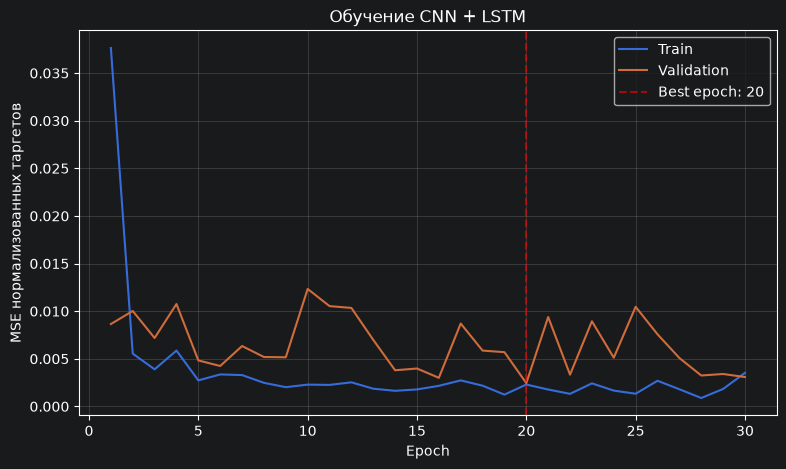

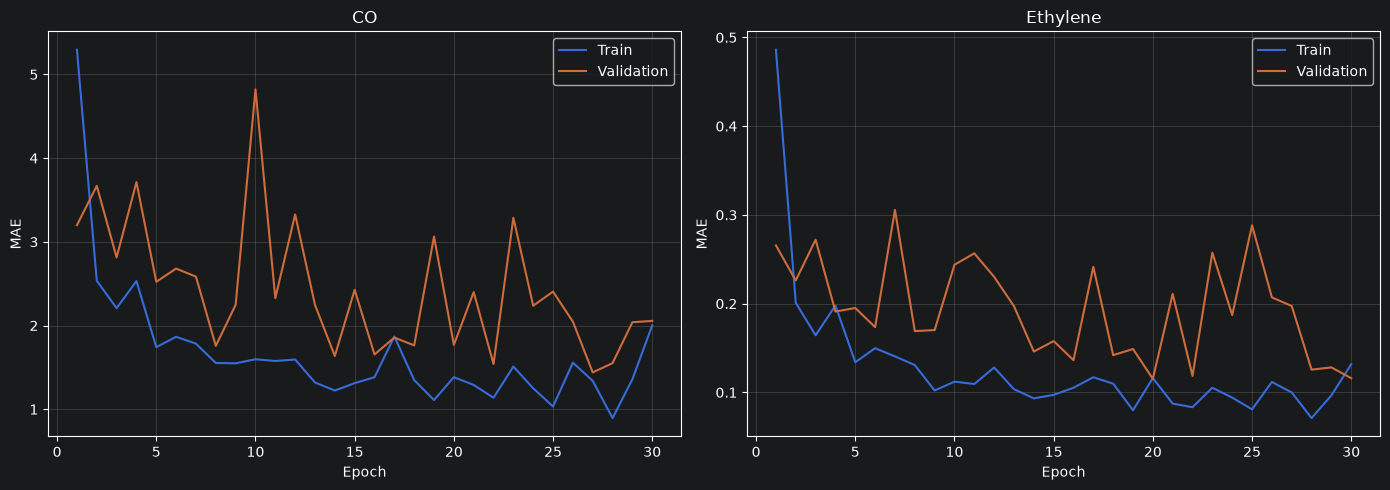

In [51]:
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train",
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    alpha=0.6,
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("MSE нормализованных таргетов")
plt.title("Обучение CNN + LSTM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# %%
# Графики MAE отдельно для двух газов

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history["train_co_mae"],
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_co_mae"],
    label="Validation",
)

axes[0].set_title("CO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_ethylene_mae"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_ethylene_mae"],
    label="Validation",
)

axes[1].set_title("Ethylene")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
def collect_predictions(
    model,
    loader,
    device,
    target_mean,
    target_std,
):
    model.eval()

    target_mean_t = torch.as_tensor(
        target_mean,
        dtype=torch.float32,
        device=device,
    )

    target_std_t = torch.as_tensor(
        target_std,
        dtype=torch.float32,
        device=device,
    )

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            pred_normalized = model(batch_x)

            pred = (
                pred_normalized * target_std_t
                + target_mean_t
            )

            true = (
                batch_y * target_std_t
                + target_mean_t
            )

            all_predictions.append(pred.cpu())
            all_targets.append(true.cpu())

    return (
        torch.cat(all_predictions).numpy(),
        torch.cat(all_targets).numpy(),
    )


test_pred, test_true = collect_predictions(
    model,
    test_loader,
    device,
    target_mean,
    target_std,
)

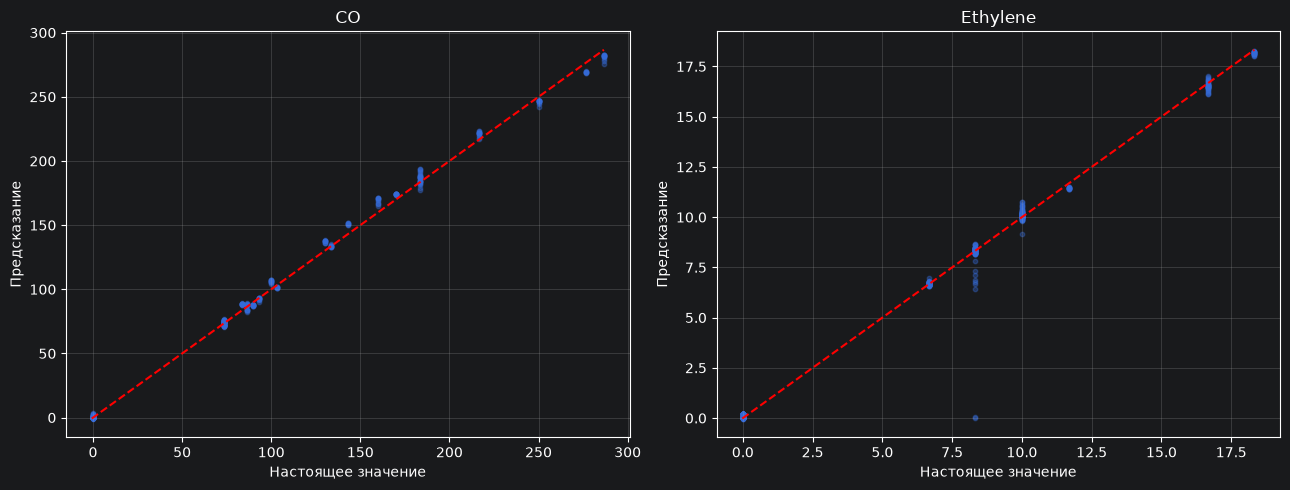

In [53]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

names = ["CO", "Ethylene"]

for i, name in enumerate(names):
    axes[i].scatter(
        test_true[:, i],
        test_pred[:, i],
        s=10,
        alpha=0.35,
    )

    minimum = min(
        test_true[:, i].min(),
        test_pred[:, i].min(),
    )

    maximum = max(
        test_true[:, i].max(),
        test_pred[:, i].max(),
    )

    axes[i].plot(
        [minimum, maximum],
        [minimum, maximum],
        color="red",
        linestyle="--",
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Настоящее значение")
    axes[i].set_ylabel("Предсказание")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
for i, name in enumerate(["CO", "Ethylene"]):
    true = test_true[:, i]
    pred = test_pred[:, i]

    zero_mask = true == 0
    nonzero_mask = true > 0

    print(name)

    if zero_mask.any():
        zero_mae = np.abs(
            pred[zero_mask] - true[zero_mask]
        ).mean()

        print("  MAE при target = 0:", zero_mae)

    if nonzero_mask.any():
        nonzero_mae = np.abs(
            pred[nonzero_mask] - true[nonzero_mask]
        ).mean()

        print("  MAE при target > 0:", nonzero_mae)

CO
  MAE при target = 0: 0.32003233
  MAE при target > 0: 3.3903103
Ethylene
  MAE при target = 0: 0.03357505
  MAE при target > 0: 0.19404888


CO


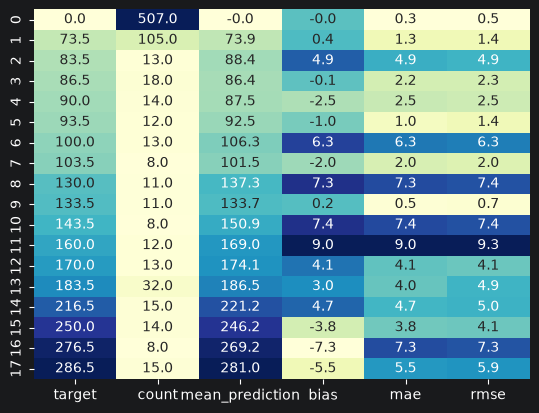

Ethylene


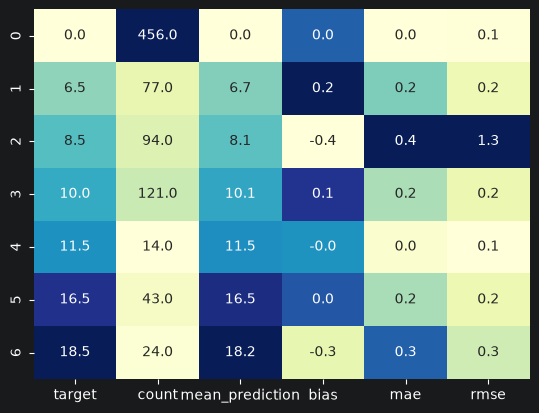

In [55]:
def metrics_by_target_value(
    true,
    pred,
    name,
    round_step=0.5,
):
    values = (
        np.round(true / round_step)
        * round_step
    )

    table = pd.DataFrame({
        "target": values,
        "prediction": pred,
    })

    table["error"] = (
        table["prediction"] - table["target"]
    )

    result = (
        table
        .groupby("target")
        .agg(
            count=("error", "size"),
            mean_prediction=("prediction", "mean"),
            bias=("error", "mean"),
            mae=("error", lambda x: np.abs(x).mean()),
            rmse=("error", lambda x: np.sqrt(np.square(x).mean())),
        )
        .reset_index()
    )

    print(name)
    df_normalized = (result - result.min(axis=0)) / (result.max(axis=0) - result.min(axis=0))

# Шаг 2: Строим heatmap по нормализованным данным, но подписи (annot) берем из исходных
    sns.heatmap(df_normalized, annot=result, fmt='.1f', cmap='YlGnBu', cbar=False)
    plt.show()

    return result


co_table = metrics_by_target_value(
    test_true[:, 0],
    test_pred[:, 0],
    name="CO",
)

ethylene_table = metrics_by_target_value(
    test_true[:, 1],
    test_pred[:, 1],
    name="Ethylene",
)